In [1]:
%load_ext autoreload

In [15]:
import pymc as pm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pickle
import xarray as xr

%autoreload
import covid19_inference.covid19_inference as cov19
import utils
import plot
#import results.R_model_full.utils_for_R_model_full as utils

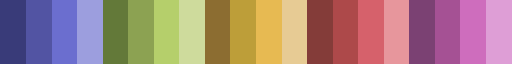

In [3]:
# colormap for plots
from matplotlib import colormaps
colormap = colormaps['tab20b']
colormap

# Input data

## Mobility

In [4]:
path_mobility = "data/mobility/mobilityData_OverviewBL_weekly.csv"
mobility_df = pd.read_csv(path_mobility, parse_dates=True, index_col=0, delimiter=";")
mobility_df = mobility_df[mobility_df["BundeslandID"] == "Deutschland"]
mobility_df["week"] = mobility_df.index.isocalendar().week

# get dates
mobility_dates = mobility_df.index.values
mobility_dates_2020 = mobility_dates[mobility_dates < np.datetime64('2020-12-20')]
mobility_dates_2020 = mobility_dates_2020[mobility_dates_2020 > np.datetime64('2020-03-29')]
mobility_dates_2022 = mobility_dates[mobility_dates < np.datetime64('2022-12-20')]
mobility_dates_2022_shortened = mobility_dates_2022[-len(mobility_dates_2020):]

# get mobility data
mobility_df_2020 = mobility_df.filter(items=mobility_dates_2020, axis=0)
mobility_data_2020 = mobility_df_2020["outOfHomeDuration"].to_xarray()

baseline_mobility_df = pd.read_csv("data/mobility/baseline_mobility.csv", parse_dates=True, index_col=0)
baseline_mobility_df = baseline_mobility_df.filter(items=mobility_dates_2022_shortened, axis=0)
# replace index by mobility dates 2020
baseline_mobility_df.index = mobility_dates_2020
# rename index to "date"
baseline_mobility_df.index.name = "date"
baseline_mobility = baseline_mobility_df["outOfHomeDuration"].to_xarray()

# convert dates to datetime
dates = pd.to_datetime(mobility_dates_2020)

## Effective Reproduction Number

In [5]:
path_R = "data/R/Germany/R_eff_Germany.csv"
R_df = pd.read_csv(path_R, index_col=1, parse_dates=True)

# weekly average placed on Sunday
df = utils.weekly_formatting(R_df, mobility_dates_2020)
df = utils.transform_data(df["R_eff median"])
R_data = df.to_xarray()

# plot R data
#R_data.plot()

## Our World in Data

In [6]:
cov19.data_retrieval.set_data_dir("/data.nst/eiftekhar/covid19/")
owid = cov19.data_retrieval.OWD()
owid.download_all_available_data()
#owid.data.columns

INFO     [covid19_inference.covid19_inference.data_retrieval.retrieval] Successfully loaded OurWorldinData.csv.gz from /data.nst/eiftekhar/covid19/, skipping download.


### ICU

In [7]:
ICU_data = owid._filter(
    value = "icu_patients_per_million", 
    country="Germany", 
    )
ICU_data = utils.weekly_formatting(ICU_data, mobility_dates_2020)
ICU_data = utils.transform_data(ICU_data).to_xarray()

### Cases

In [8]:
case_data = owid._filter(
    value = "new_cases_smoothed_per_million", 
    country="Germany", 
    )
case_data = utils.weekly_formatting(case_data, mobility_dates_2020)
case_data = utils.transform_data(case_data).to_xarray()

### Hospitalisations

In [9]:
H_data = owid._filter(
    value = "weekly_hosp_admissions_per_million", 
    country="Germany", 
    )
H_data = utils.weekly_formatting(H_data, mobility_dates_2020)
H_data = utils.transform_data(H_data).to_xarray()

## Non-pharmaceutical interventions

In [10]:
stay_at_home_2020 = utils.get_NPI_data("data/NPIs/stay-at-home-covid.csv", mobility_dates_2020)
stay_at_home_2020 = utils.transform_data(stay_at_home_2020)
stay_at_home_2020 = stay_at_home_2020['stay_home_requirements'].to_xarray()

/data/eiftekhar/mobility_inference/utils.py:19: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = df.resample("7D").mean()


## Weather

In [11]:
weather_df = pd.read_csv(
    "data/weather/weatherData2020and2022.csv", parse_dates=True, index_col=0
)

### filter for mobility_dates_2020
weather_df_2020 = weather_df[weather_df.index.isin(mobility_dates_2020)]
weather_df_2022 = weather_df[weather_df.index.isin(mobility_dates_2022_shortened)]

### calculate differences between the years
delta_tmax = utils.return_differences(weather_df_2020, weather_df_2022, "tmax")
delta_tmax = xr.DataArray(
    delta_tmax, dims="date", coords={"date": mobility_dates_2020}, name="delta_tmax"
)

### calculate average between the years
average_tmax = utils.return_averages(weather_df_2020, weather_df_2022, "tmax")
average_tmax = xr.DataArray(
    average_tmax, dims="date", coords={"date": mobility_dates_2020}, name="average_tmax"
)

# Plotting

In [12]:
# load trace from file
def load_trace(tag_in):
    path = f"results/{tag_in}/trace_{tag_in}.pickle"
    with open(path, "rb") as inference_file:
        trace = pickle.load(inference_file)
    return trace

# load model
def load_model(indicators_in, data_in):
    model = pm.Model()
    utils.create_model(
        model,
        baseline_mobility,
        mobility_data_2020,
        stay_at_home_2020,
        delta_tmax,
        average_tmax,
        indicators_in,
        data_in
    )
    return model

## Cases

In [13]:
# load trace from file
tag = "C_test"
indicators = ["C"]
C_trace = load_trace(tag)
C_model = load_model(indicators, {'C': case_data})

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [41]:
az.summary(C_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
offset,24.966,2.135,21.272,29.551,0.123,0.087,302.0,282.0,1.02
shift,-19.852,1.888,-23.762,-16.757,0.115,0.082,261.0,209.0,1.01
z_C,0.137,0.026,0.094,0.185,0.001,0.001,343.0,311.0,1.00
mu_C,1.657,0.448,0.939,2.608,0.030,0.022,241.0,230.0,1.00
sigma_C,0.850,0.225,0.455,1.259,0.015,0.011,254.0,132.0,1.00
...,...,...,...,...,...,...,...,...,...
m[32],6.212,0.142,5.982,6.481,0.008,0.006,309.0,334.0,1.01
m[33],6.057,0.144,5.799,6.296,0.008,0.006,296.0,276.0,1.01
m[34],5.981,0.145,5.720,6.215,0.009,0.006,287.0,275.0,1.00
m[35],5.944,0.145,5.682,6.180,0.009,0.006,286.0,268.0,1.00


Sampling: [z_T]
INFO     [pymc] Sampling: [z_T]


Directory  figures/C_test  already exists.


Sampling: [amplitude]
INFO     [pymc] Sampling: [amplitude]
Sampling: [offset]
INFO     [pymc] Sampling: [offset]
Sampling: [shift]
INFO     [pymc] Sampling: [shift]
Sampling: [a_r]
INFO     [pymc] Sampling: [a_r]
Sampling: [sigma_model]
INFO     [pymc] Sampling: [sigma_model]
Sampling: [z_S]
INFO     [pymc] Sampling: [z_S]
Sampling: [z_C]
INFO     [pymc] Sampling: [z_C]
Sampling: [mu_C]
INFO     [pymc] Sampling: [mu_C]
Sampling: [sigma_C]
INFO     [pymc] Sampling: [sigma_C]


(400, 37)
(400, 37)
(400, 37)
(400, 37)
(400, 37)
(400, 37)


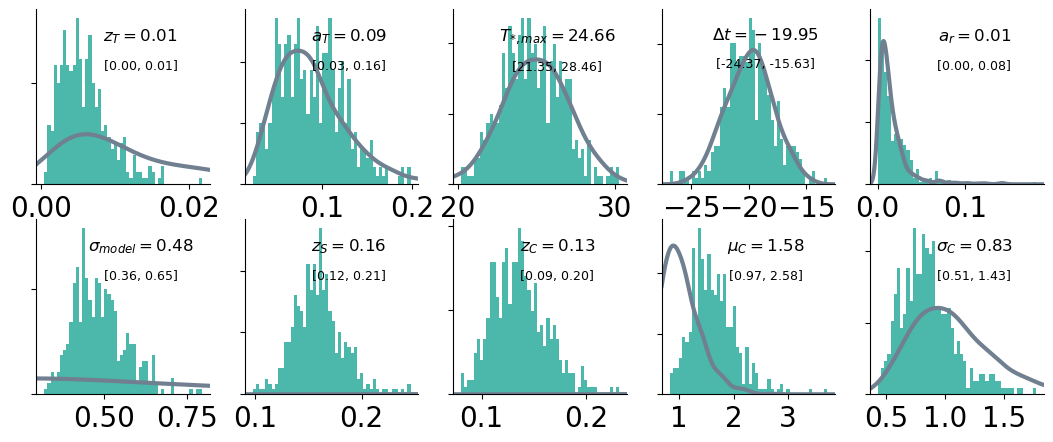

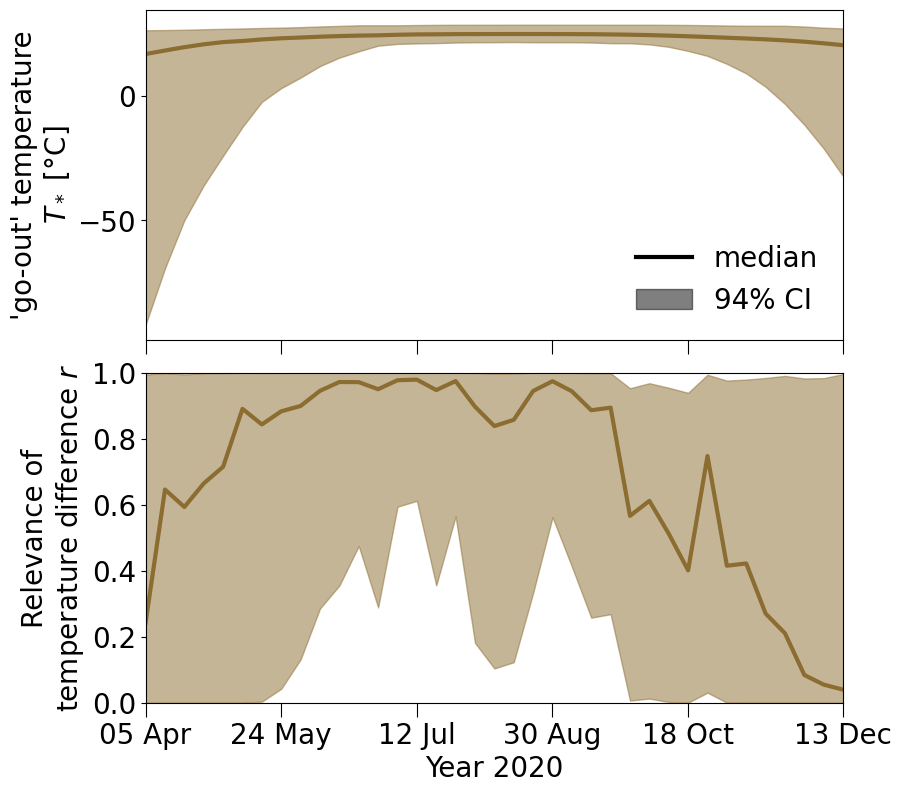

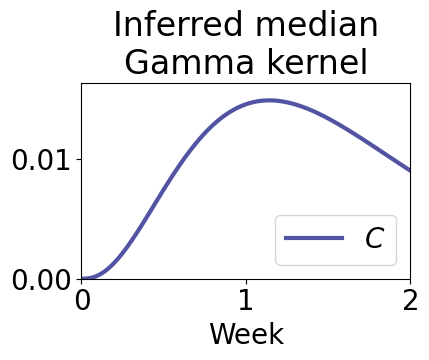

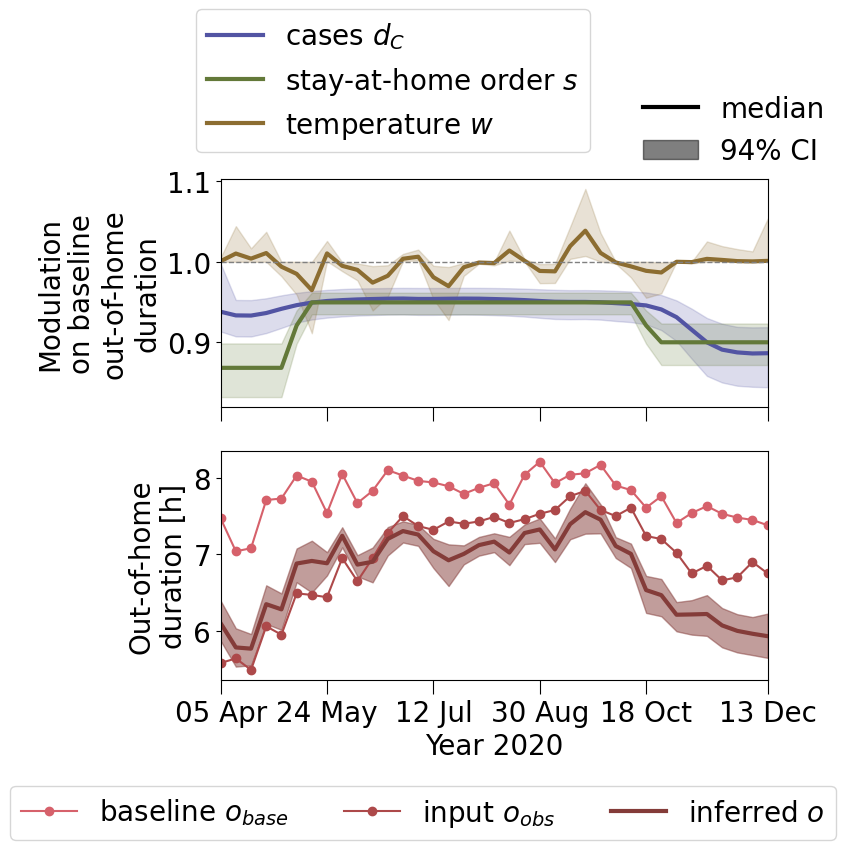

In [16]:
plot.analysis_figures(C_model, C_trace, tag, dates, indicators)

## R

In [82]:
# load trace from file
tag = "R_model_full"
R_trace = load_trace(tag)

# load model
R_model = load_model(R_data)

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [48]:
az.summary(R_trace, 
           #var_names=["a", "mu_R", "sigma_R", "sigma"], 
           round_to=2
           )

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
offset,24.93,2.02,20.56,28.29,0.10,0.07,440.85,287.91,1.00
shift,-19.90,1.83,-23.42,-16.32,0.08,0.06,538.77,286.99,1.00
z,0.12,0.02,0.08,0.15,0.00,0.00,250.11,291.99,1.00
mu,0.91,0.22,0.51,1.34,0.01,0.01,334.01,177.07,1.01
sigma,1.17,0.34,0.61,1.84,0.02,0.01,343.20,235.48,1.01
...,...,...,...,...,...,...,...,...,...
m[32],6.50,0.10,6.33,6.67,0.01,0.00,318.19,310.04,1.00
m[33],6.41,0.09,6.25,6.57,0.01,0.00,318.76,349.16,1.00
m[34],6.37,0.09,6.21,6.52,0.00,0.00,320.85,347.95,1.00
m[35],6.33,0.09,6.16,6.46,0.00,0.00,315.94,253.86,1.00


array([[<Axes: title={'center': 'offset'}>,
        <Axes: title={'center': 'offset'}>],
       [<Axes: title={'center': 'shift'}>,
        <Axes: title={'center': 'shift'}>],
       [<Axes: title={'center': 'z'}>, <Axes: title={'center': 'z'}>],
       [<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'z_S'}>, <Axes: title={'center': 'z_S'}>],
       [<Axes: title={'center': 'z_T'}>, <Axes: title={'center': 'z_T'}>],
       [<Axes: title={'center': 'amplitude'}>,
        <Axes: title={'center': 'amplitude'}>],
       [<Axes: title={'center': 'a_r'}>, <Axes: title={'center': 'a_r'}>],
       [<Axes: title={'center': 'sigma_model'}>,
        <Axes: title={'center': 'sigma_model'}>],
       [<Axes: title={'center': 'd'}>, <Axes: title={'center': 'd'}>],
       [<Axes: title={'center': 's'}>, <Axes: title={'center': 's'}>],
       [<Axes: title={'center': 

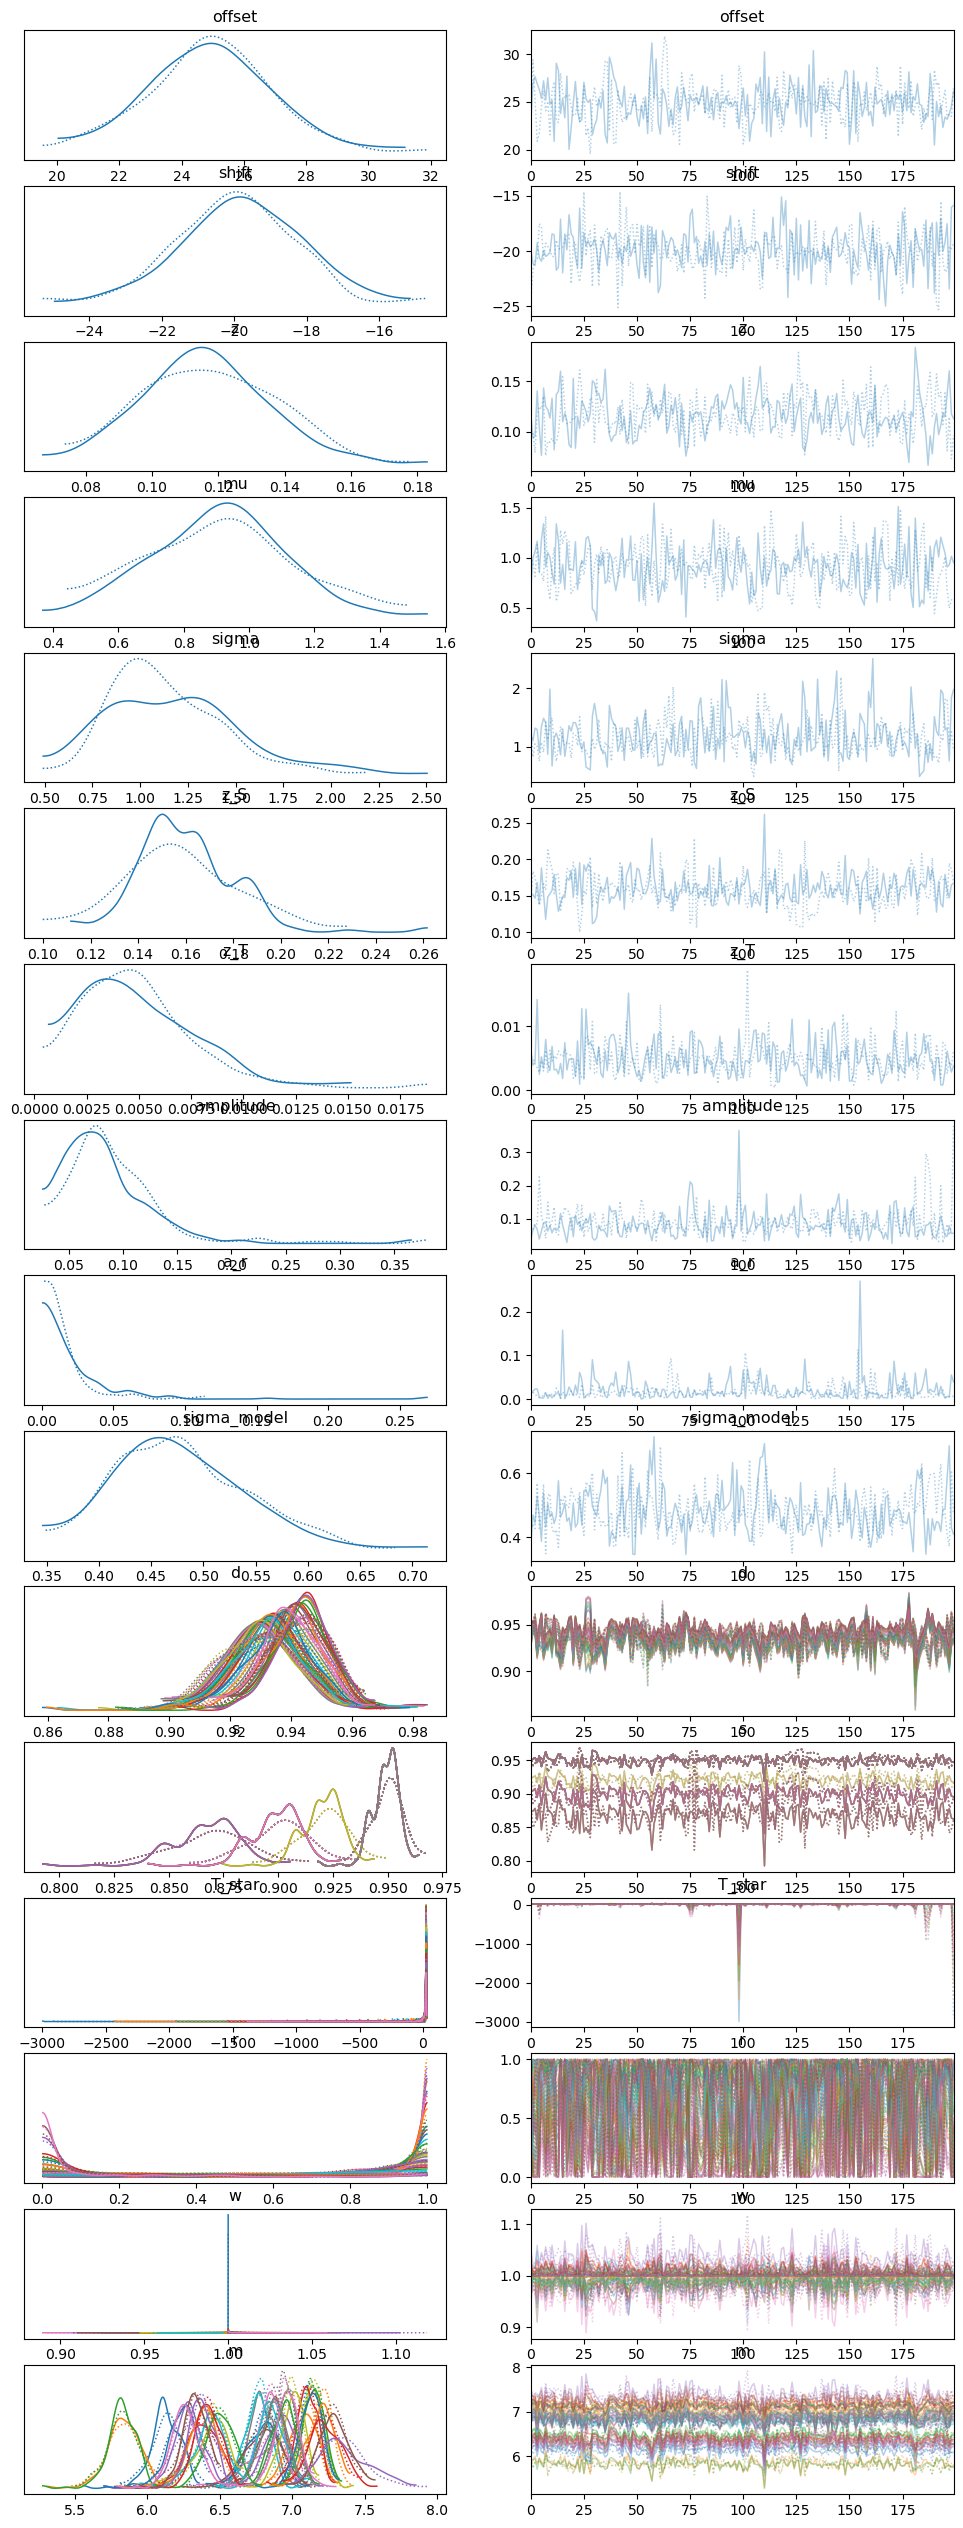

In [65]:
# plot chains
az.plot_trace(R_trace, compact=True)

Sampling: [z]
INFO     [pymc] Sampling: [z]
Sampling: [mu]
INFO     [pymc] Sampling: [mu]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]
Sampling: [sigma_model]
INFO     [pymc] Sampling: [sigma_model]
Sampling: [z_S]
INFO     [pymc] Sampling: [z_S]
Sampling: [z_T]
INFO     [pymc] Sampling: [z_T]
Sampling: [amplitude]
INFO     [pymc] Sampling: [amplitude]
Sampling: [offset]
INFO     [pymc] Sampling: [offset]
Sampling: [shift]
INFO     [pymc] Sampling: [shift]
Sampling: [a_r]
INFO     [pymc] Sampling: [a_r]


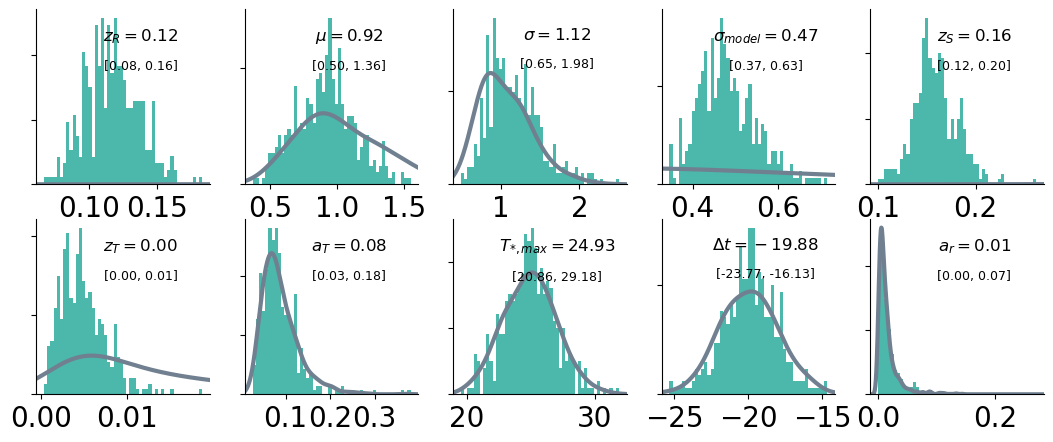

In [70]:
plot_distributions(R_model, R_trace, tag, 'z_R')

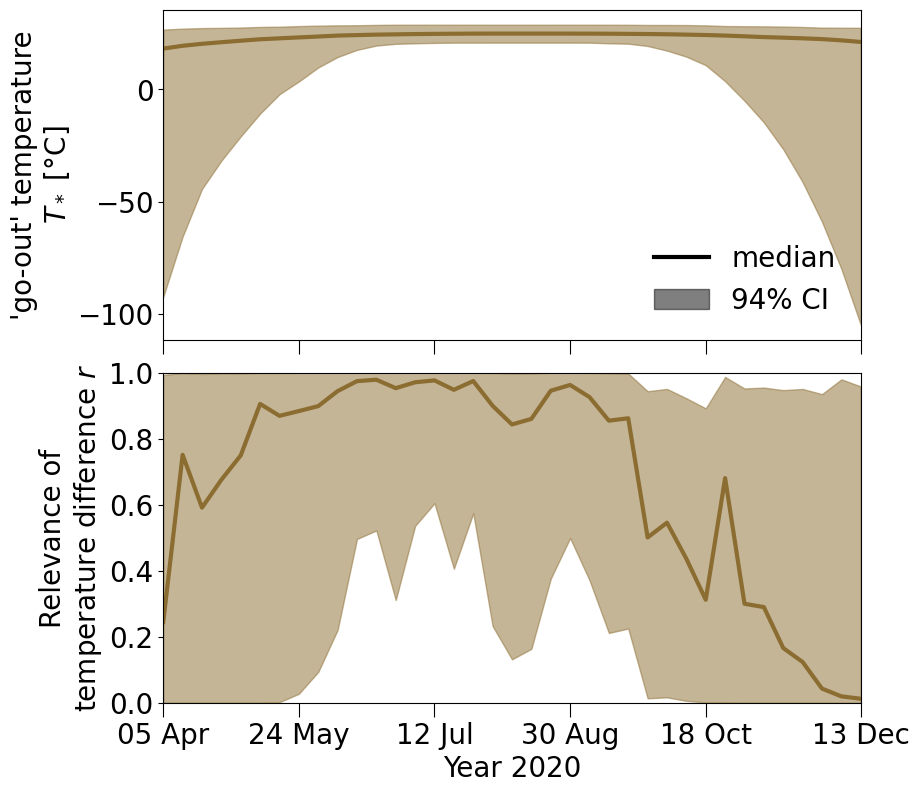

In [50]:
plot_temperature_timeseries(dates, R_trace, tag)

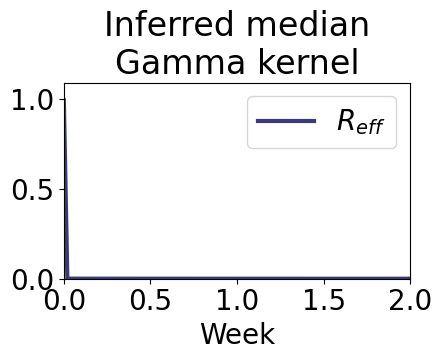

In [12]:
plot_gamma_kernel(R_trace, tag, {"mu": "mu", "sigma": "sigma", "label": "$R_{eff}$", "color": color_R})

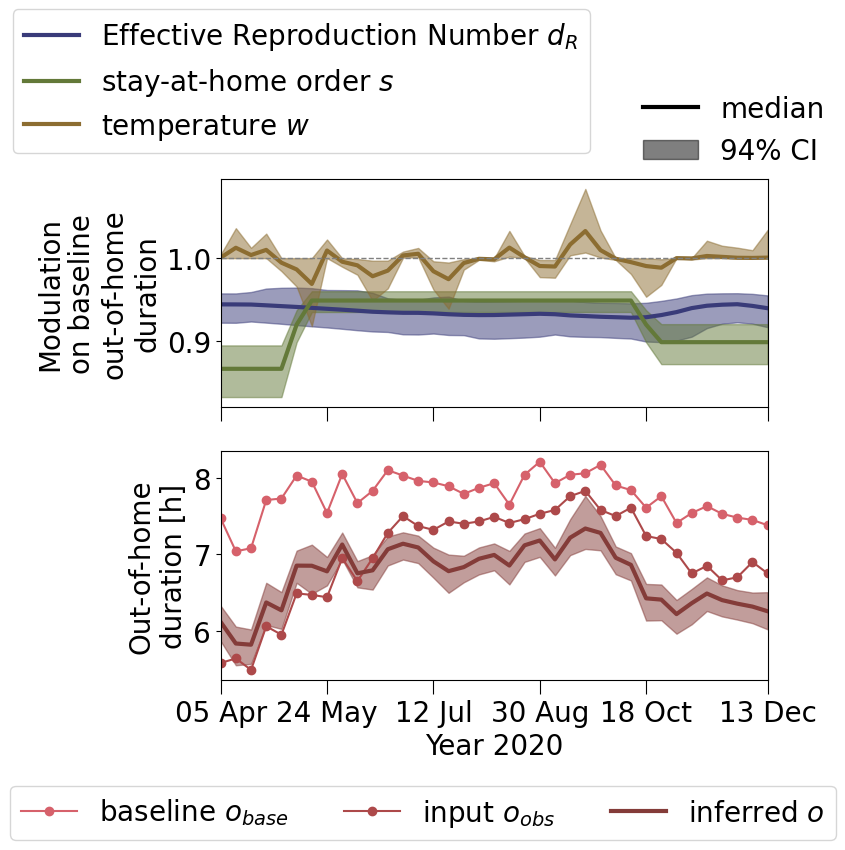

In [83]:
plot_out_of_home_duration_timeseries(
  dates,
  R_trace,
  tag,
  {
    "color": color_R,
    "del": "d",
    "del_label": "Effective Reproduction Number $d_R$",
  },
)

## ICU

In [84]:
# load trace from file
tag = "ICU_model_full"
ICU_trace = load_trace(tag)
ICU_model = load_model(ICU_data)

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [67]:
az.summary(ICU_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
offset,25.051,2.060,21.383,28.895,0.111,0.079,348.0,282.0,1.01
shift,-19.886,1.888,-23.688,-16.687,0.099,0.070,361.0,282.0,1.01
z,0.139,0.020,0.103,0.178,0.001,0.001,257.0,206.0,1.01
mu,1.746,0.502,0.875,2.689,0.034,0.024,220.0,240.0,1.01
sigma,0.867,0.232,0.403,1.226,0.014,0.010,254.0,257.0,1.02
...,...,...,...,...,...,...,...,...,...
m[32],6.413,0.111,6.207,6.596,0.006,0.005,293.0,335.0,1.01
m[33],6.224,0.111,6.027,6.403,0.006,0.004,334.0,258.0,1.00
m[34],6.112,0.107,5.922,6.303,0.006,0.004,341.0,272.0,1.00
m[35],6.048,0.107,5.858,6.241,0.006,0.004,341.0,315.0,1.00


Sampling: [z]
INFO     [pymc] Sampling: [z]


Sampling: [mu]
INFO     [pymc] Sampling: [mu]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]
Sampling: [sigma_model]
INFO     [pymc] Sampling: [sigma_model]
Sampling: [z_S]
INFO     [pymc] Sampling: [z_S]
Sampling: [z_T]
INFO     [pymc] Sampling: [z_T]
Sampling: [amplitude]
INFO     [pymc] Sampling: [amplitude]
Sampling: [offset]
INFO     [pymc] Sampling: [offset]
Sampling: [shift]
INFO     [pymc] Sampling: [shift]
Sampling: [a_r]
INFO     [pymc] Sampling: [a_r]


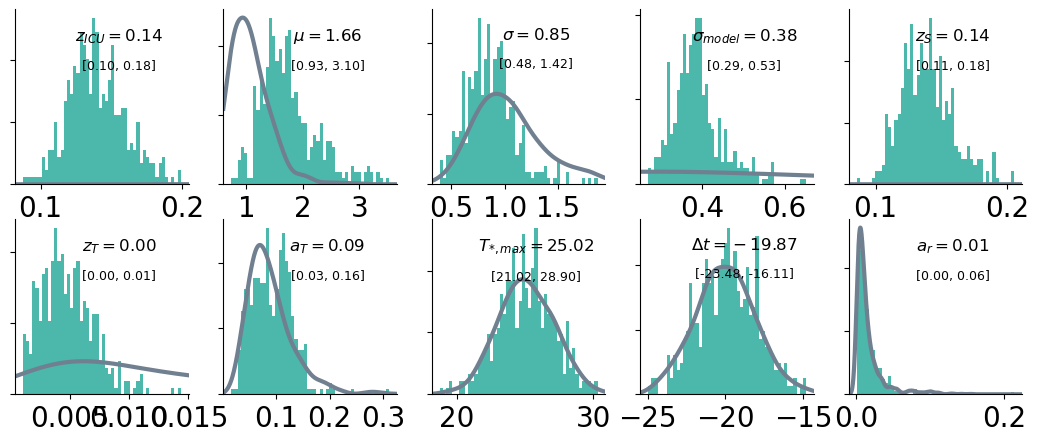

In [77]:
plot_distributions(ICU_model, ICU_trace, tag, 'z_{ICU}')

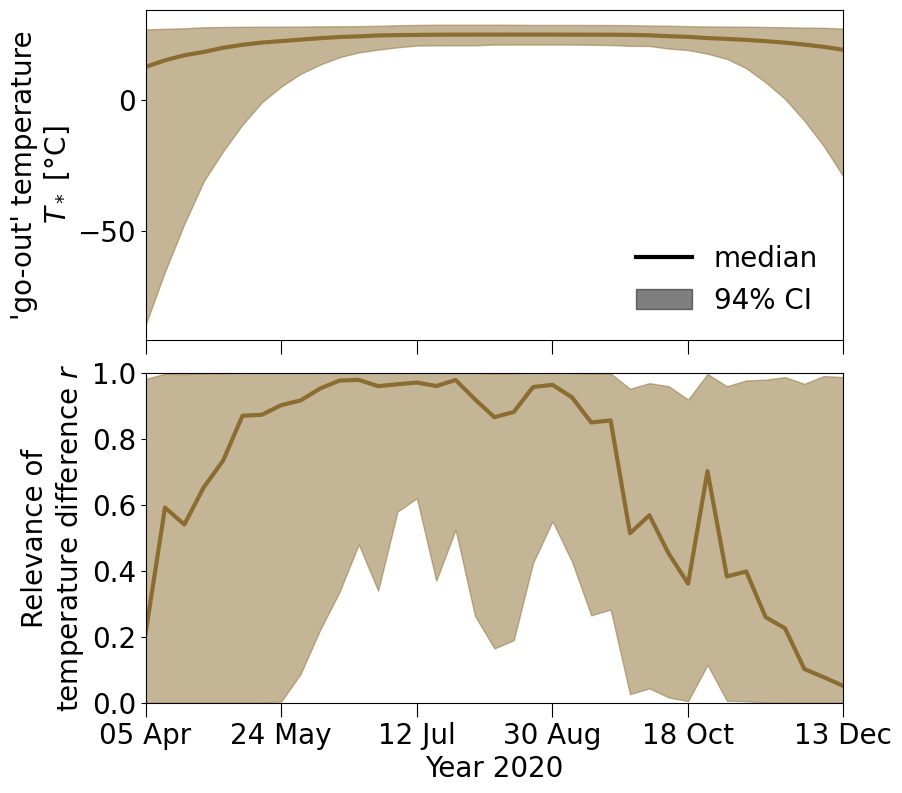

In [78]:
plot_temperature_timeseries(dates, ICU_trace, tag)

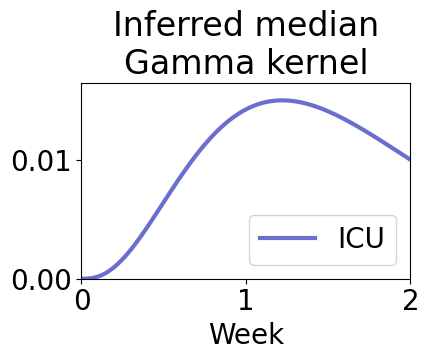

In [80]:
plot_gamma_kernel(ICU_trace, tag, {"mu": "mu", "sigma": "sigma", "label": "ICU", "color": color_ICU})

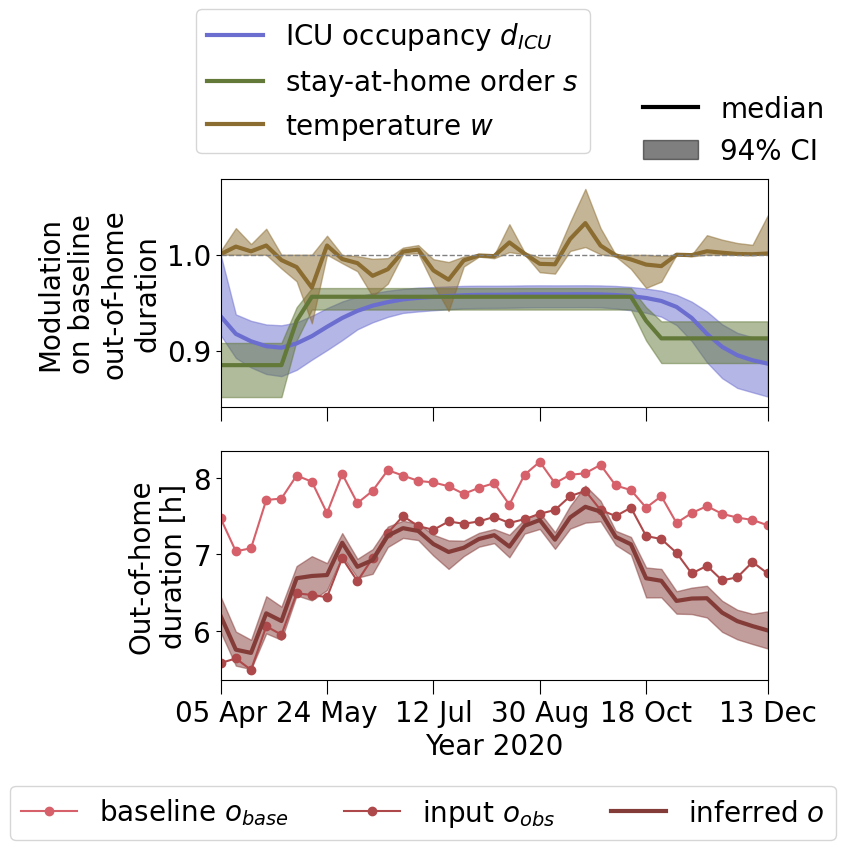

In [85]:
plot_out_of_home_duration_timeseries(
  dates,
  ICU_trace,
  tag,
  {
    "color": color_ICU,
    "del": "d",
    "del_label": "ICU occupancy $d_{ICU}$",
  },
)

## Hospitalisations

In [102]:
# load trace from file
tag = "H_model_full"
H_trace = load_trace(tag)
H_model = load_model(H_data)

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [100]:
az.summary(H_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
offset,25.225,2.130,21.262,29.044,0.125,0.089,282.0,240.0,1.01
shift,-19.864,2.042,-23.956,-16.314,0.104,0.075,389.0,241.0,1.00
z,0.139,0.022,0.104,0.185,0.001,0.001,350.0,365.0,1.02
mu,1.677,0.446,1.001,2.541,0.032,0.023,183.0,306.0,1.02
sigma,0.856,0.217,0.490,1.227,0.014,0.010,217.0,215.0,1.01
...,...,...,...,...,...,...,...,...,...
m[32],6.289,0.127,6.050,6.517,0.007,0.005,352.0,365.0,1.00
m[33],6.139,0.125,5.912,6.363,0.007,0.005,357.0,365.0,1.00
m[34],6.050,0.125,5.837,6.282,0.007,0.005,367.0,365.0,1.00
m[35],6.000,0.126,5.777,6.219,0.007,0.005,382.0,365.0,1.00


Sampling: [z]
INFO     [pymc] Sampling: [z]


Sampling: [mu]
INFO     [pymc] Sampling: [mu]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]
Sampling: [sigma_model]
INFO     [pymc] Sampling: [sigma_model]
Sampling: [z_S]
INFO     [pymc] Sampling: [z_S]
Sampling: [z_T]
INFO     [pymc] Sampling: [z_T]
Sampling: [amplitude]
INFO     [pymc] Sampling: [amplitude]
Sampling: [offset]
INFO     [pymc] Sampling: [offset]
Sampling: [shift]
INFO     [pymc] Sampling: [shift]
Sampling: [a_r]
INFO     [pymc] Sampling: [a_r]


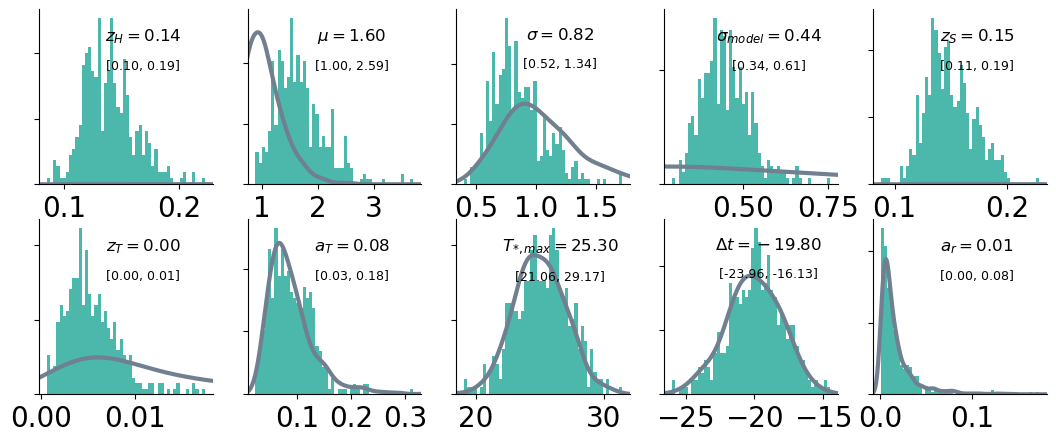

In [103]:
plot_distributions(H_model, H_trace, tag, 'z_{H}')

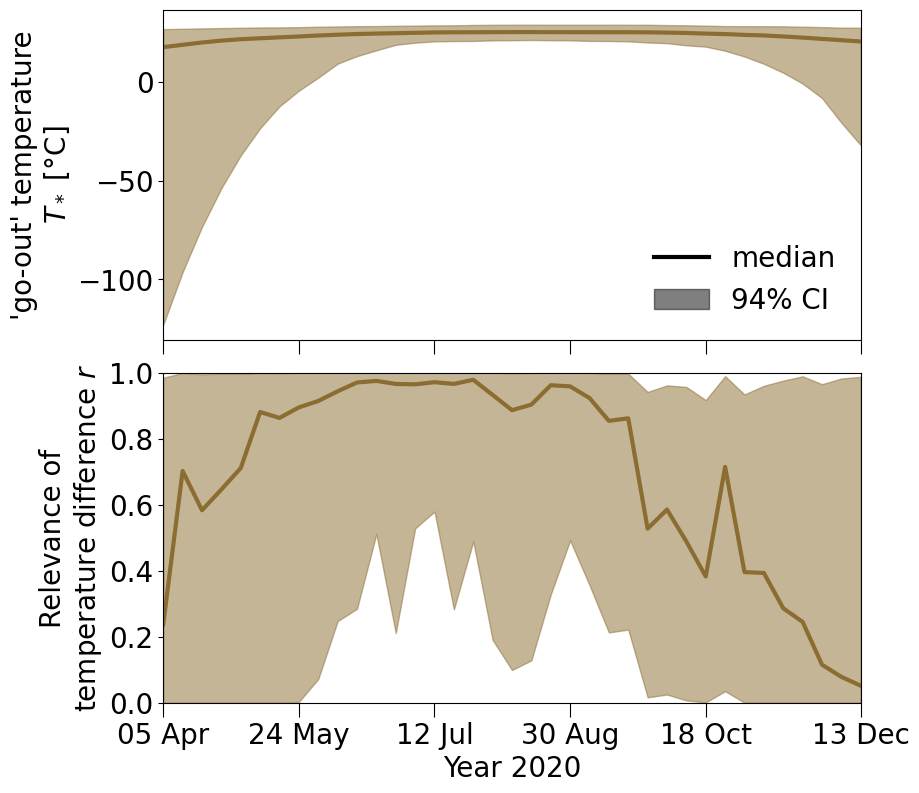

In [104]:
plot_temperature_timeseries(dates, H_trace, tag)

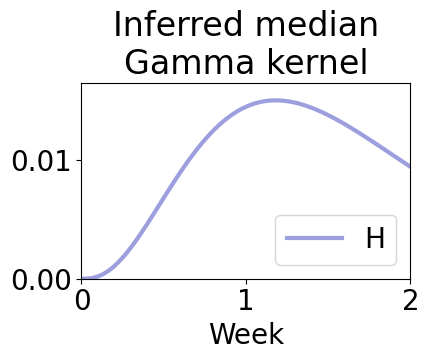

In [106]:
plot_gamma_kernel(H_trace, tag, {"mu": "mu", "sigma": "sigma", "label": "H", "color": color_H})

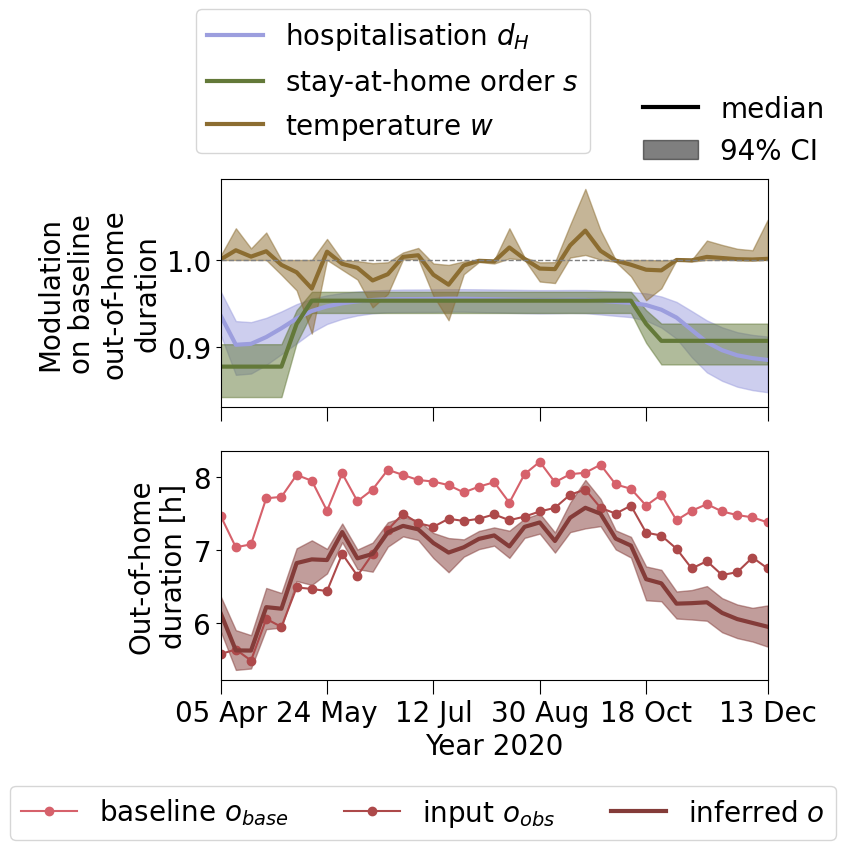

In [107]:
plot_out_of_home_duration_timeseries(
  dates,
  H_trace,
  tag,
  {
    "color": color_H,
    "del": "d",
    "del_label": "hospitalisation $d_{H}$",
  },
)

## R + cases model

In [8]:
tag = "R+cases_model_test"
RC_trace = load_trace(tag)

In [82]:
az.summary(RC_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.892,0.075,0.760,1.034,0.003,0.002,549.0,539.0,1.0
c,-0.001,0.000,-0.001,0.000,0.000,0.000,507.0,525.0,1.0
mu_R,1.569,0.242,1.135,1.990,0.012,0.009,534.0,326.0,1.0
sigma_R,1.475,0.135,1.217,1.717,0.005,0.004,721.0,641.0,1.0
mu_ICU,2.269,0.430,1.420,3.017,0.015,0.011,786.0,553.0,1.0
...,...,...,...,...,...,...,...,...,...
m[35],7.016,0.101,6.845,7.215,0.003,0.002,840.0,559.0,1.0
m[36],6.946,0.101,6.775,7.146,0.003,0.002,841.0,580.0,1.0
m[37],6.866,0.100,6.695,7.067,0.003,0.002,841.0,628.0,1.0
m[38],6.834,0.100,6.661,7.035,0.003,0.002,828.0,628.0,1.0


Sampling: [a]
INFO     [pymc] Sampling: [a]
Sampling: [mu_R]
INFO     [pymc] Sampling: [mu_R]
Sampling: [sigma_R]
INFO     [pymc] Sampling: [sigma_R]
Sampling: [c]
INFO     [pymc] Sampling: [c]
Sampling: [mu_C]
INFO     [pymc] Sampling: [mu_C]
Sampling: [sigma_C]
INFO     [pymc] Sampling: [sigma_C]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]


[<Axes: >]

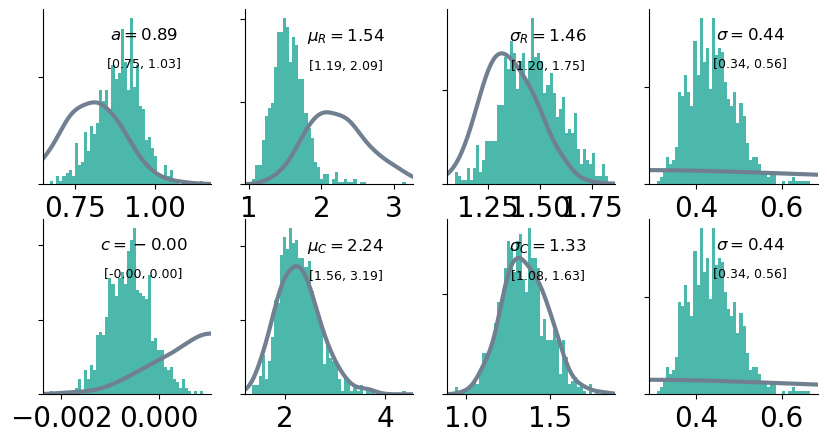

In [86]:
fig, axs = plt.subplots(2, 4, figsize=(10, 5))

cov19.plot.distribution(RC_model, RC_trace, 'a', dist_math='a', ax=axs[0,0])
cov19.plot.distribution(RC_model, RC_trace, 'mu_R', dist_math='\mu_R', ax=axs[0,1])
cov19.plot.distribution(RC_model, RC_trace, 'sigma_R', dist_math='\sigma_R', ax=axs[0,2])
cov19.plot.distribution(RC_model, RC_trace, 'c', dist_math='c', ax=axs[1,0])
cov19.plot.distribution(RC_model, RC_trace, 'mu_C', dist_math='\mu_{C}', ax=axs[1,1])
cov19.plot.distribution(RC_model, RC_trace, 'sigma_C', dist_math='\sigma_{C}', ax=axs[1,2])
cov19.plot.distribution(RC_model, RC_trace, 'sigma', dist_math='\sigma', ax=axs[0,3])
cov19.plot.distribution(RC_model, RC_trace, 'sigma', dist_math='\sigma', ax=axs[1,3])

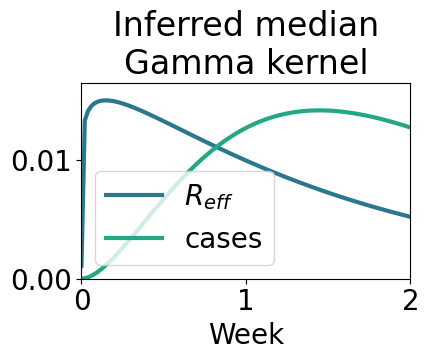

In [47]:
plot_gamma_kernel(RC_trace, 
                  tag, 
                  {"mu": "mu_R", "sigma": "sigma_R", "label": "$R_{eff}$", "color": color_R},
                  {"mu": "mu_C", "sigma": "sigma_C", "label": "cases", "color": color_C},
                  )

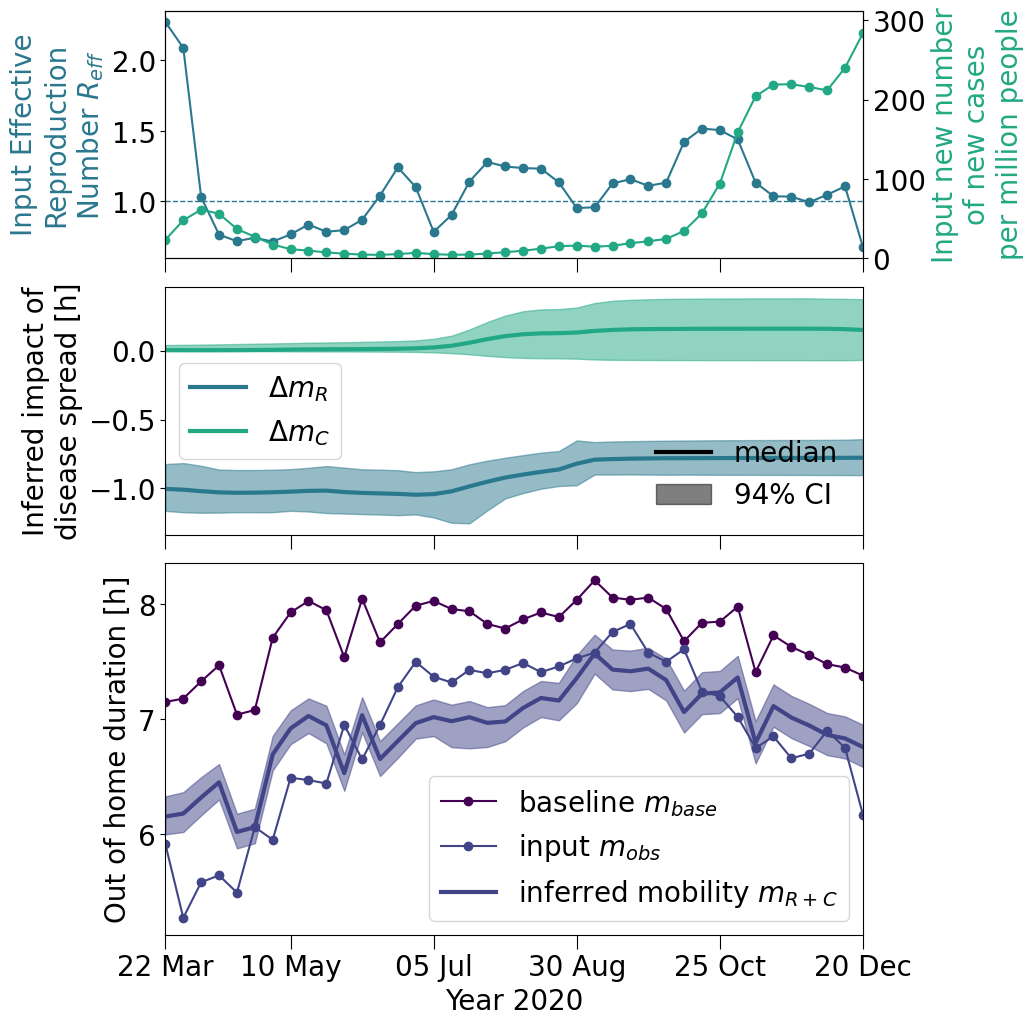

In [66]:
plot_inference_timeseries(
                          dates,
                          RC_trace,
                          tag,
                          {
                            "constant": "R_eff", 
                            "color": color_R,
                            "data_label": f"Input Effective\nReproduction\nNumber $R_{{eff}}$",
                            "del": "del_m_R",
                            "del_label": "$\Delta m_R$",
                            "color_del": color_del_m_R,
                            "m": "m",
                            "m_label": "inferred mobility $m_{R+C}$",
                          },
                          {
                            "constant": "cases",
                            "color": color_C,
                            "data_label": f"Input new number\nof new cases\nper million people",
                            "del": "del_m_C",
                            "del_label": "$\Delta m_C$",
                            "color_del": color_del_m_C,
                          },
                          )

## R + ICU model

In [9]:
tag = "R_ICU_test"
joint_trace = load_trace(tag)

In [54]:
az.summary(joint_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.850,0.084,0.693,1.006,0.004,0.003,499.0,409.0,1.00
b,-0.001,0.003,-0.006,0.004,0.000,0.000,549.0,447.0,1.00
mu_R,1.637,0.336,1.099,2.299,0.021,0.015,371.0,285.0,1.00
sigma_R,1.442,0.141,1.180,1.693,0.006,0.004,645.0,536.0,1.01
mu_ICU,2.251,0.458,1.493,3.217,0.015,0.011,876.0,736.0,1.00
...,...,...,...,...,...,...,...,...,...
m[35],6.945,0.111,6.741,7.172,0.003,0.002,1027.0,623.0,1.01
m[36],6.875,0.111,6.671,7.102,0.003,0.002,1027.0,623.0,1.01
m[37],6.795,0.111,6.592,7.021,0.003,0.002,1032.0,622.0,1.01
m[38],6.766,0.110,6.563,6.991,0.003,0.002,1040.0,648.0,1.01


Sampling: [a]
INFO     [pymc] Sampling: [a]
Sampling: [mu_R]
INFO     [pymc] Sampling: [mu_R]
Sampling: [sigma_R]
INFO     [pymc] Sampling: [sigma_R]
Sampling: [b]
INFO     [pymc] Sampling: [b]
Sampling: [mu_ICU]
INFO     [pymc] Sampling: [mu_ICU]
Sampling: [sigma_ICU]
INFO     [pymc] Sampling: [sigma_ICU]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]


[<Axes: >]

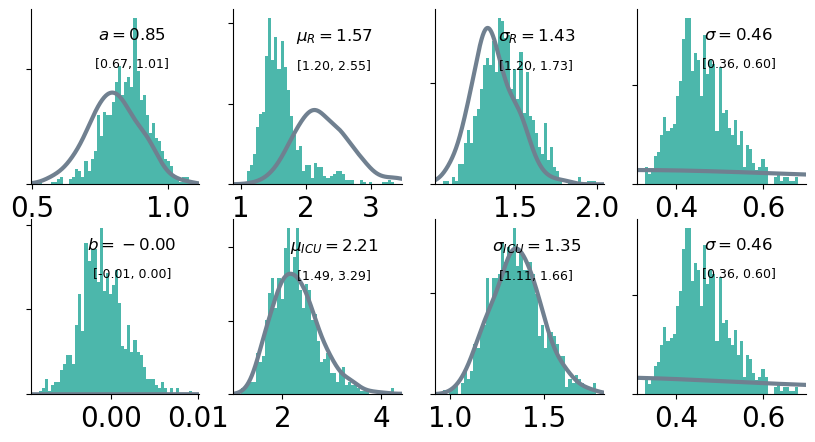

In [55]:
fig, axs = plt.subplots(2, 4, figsize=(10, 5))

cov19.plot.distribution(joint_model, joint_trace, 'a', dist_math='a', ax=axs[0,0])
cov19.plot.distribution(joint_model, joint_trace, 'mu_R', dist_math='\mu_R', ax=axs[0,1])
cov19.plot.distribution(joint_model, joint_trace, 'sigma_R', dist_math='\sigma_R', ax=axs[0,2])
cov19.plot.distribution(joint_model, joint_trace, 'b', dist_math='b', ax=axs[1,0])
cov19.plot.distribution(joint_model, joint_trace, 'mu_ICU', dist_math='\mu_{ICU}', ax=axs[1,1])
cov19.plot.distribution(joint_model, joint_trace, 'sigma_ICU', dist_math='\sigma_{ICU}', ax=axs[1,2])
cov19.plot.distribution(joint_model, joint_trace, 'sigma', dist_math='\sigma', ax=axs[0,3])
cov19.plot.distribution(joint_model, joint_trace, 'sigma', dist_math='\sigma', ax=axs[1,3])

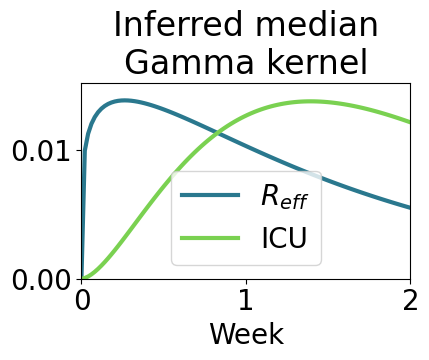

In [49]:
plot_gamma_kernel(joint_trace,
                  tag,
                  {"mu": "mu_R", "sigma": "sigma_R", "label": "$R_{eff}$", "color": color_R},
                  {"mu": "mu_ICU", "sigma": "sigma_ICU", "label": "ICU", "color": color_ICU}
                  )

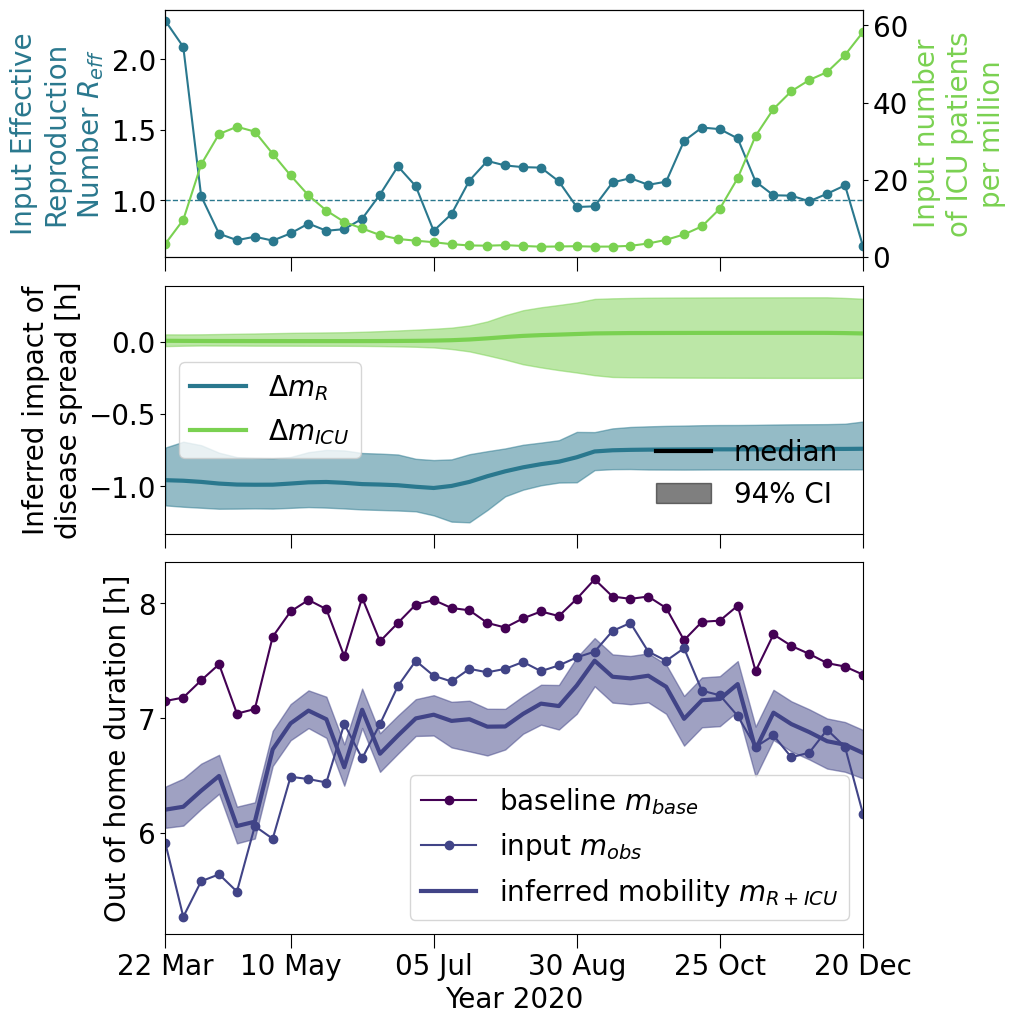

In [68]:
plot_inference_timeseries(
                          dates,
                          joint_trace,
                          tag,
                          {
                            "constant": "R_eff", 
                            "color": color_R,
                            "data_label": f"Input Effective\nReproduction\nNumber $R_{{eff}}$",
                            "del": "del_m_R",
                            "del_label": "$\Delta m_R$",
                            "color_del": color_del_m_R,
                            "m": "m",
                            "m_label": "inferred mobility $m_{R+ICU}$",
                          },
                          {
                            "constant": "ICU",
                            "color": color_ICU,
                            "data_label": f"Input number\nof ICU patients\nper million",
                            "del": "del_m_ICU",
                            "del_label": "$\Delta m_{ICU}$",
                            "color_del": color_del_m_ICU,
                          }
                          )

## All indicators

In [21]:
# load trace from file
tag = "R_C_ICU_H_test"
indicators = ['R', "C", 'ICU', 'H']
all_trace = load_trace(tag)
all_model = load_model(indicators, {'R': R_data, 'C': case_data, 'ICU': ICU_data, 'H': H_data})

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases
INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases
INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases
INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [22]:
az.summary(all_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
offset,24.970,1.949,21.628,28.878,0.100,0.071,381.0,292.0,1.01
shift,-19.877,2.049,-23.686,-15.982,0.080,0.056,662.0,252.0,1.01
z_R,0.439,0.122,0.188,0.646,0.007,0.005,385.0,158.0,1.00
mu_R,1.112,0.327,0.606,1.728,0.014,0.010,502.0,380.0,1.00
sigma_R,0.991,0.329,0.490,1.592,0.019,0.014,325.0,304.0,1.00
...,...,...,...,...,...,...,...,...,...
m[32],1.444,0.436,0.701,2.251,0.027,0.019,274.0,334.0,1.00
m[33],1.375,0.417,0.661,2.153,0.026,0.018,267.0,312.0,1.00
m[34],1.330,0.407,0.690,2.159,0.025,0.018,258.0,343.0,1.00
m[35],1.305,0.403,0.660,2.115,0.026,0.018,241.0,343.0,1.00


Directory  figures/R_C_ICU_H_test  already exists.


Sampling: [z_T]
INFO     [pymc] Sampling: [z_T]
Sampling: [amplitude]
INFO     [pymc] Sampling: [amplitude]
Sampling: [offset]
INFO     [pymc] Sampling: [offset]
Sampling: [shift]
INFO     [pymc] Sampling: [shift]
Sampling: [a_r]
INFO     [pymc] Sampling: [a_r]
Sampling: [sigma_model]
INFO     [pymc] Sampling: [sigma_model]
Sampling: [z_S]
INFO     [pymc] Sampling: [z_S]
Sampling: [z_R]
INFO     [pymc] Sampling: [z_R]
Sampling: [mu_R]
INFO     [pymc] Sampling: [mu_R]
Sampling: [sigma_R]
INFO     [pymc] Sampling: [sigma_R]
Sampling: [z_C]
INFO     [pymc] Sampling: [z_C]
Sampling: [mu_C]
INFO     [pymc] Sampling: [mu_C]
Sampling: [sigma_C]
INFO     [pymc] Sampling: [sigma_C]
Sampling: [z_ICU]
INFO     [pymc] Sampling: [z_ICU]
Sampling: [mu_ICU]
INFO     [pymc] Sampling: [mu_ICU]
Sampling: [sigma_ICU]
INFO     [pymc] Sampling: [sigma_ICU]
Sampling: [z_H]
INFO     [pymc] Sampling: [z_H]
Sampling: [mu_H]
INFO     [pymc] Sampling: [mu_H]
Sampling: [sigma_H]
INFO     [pymc] Sampling: [sigma_H

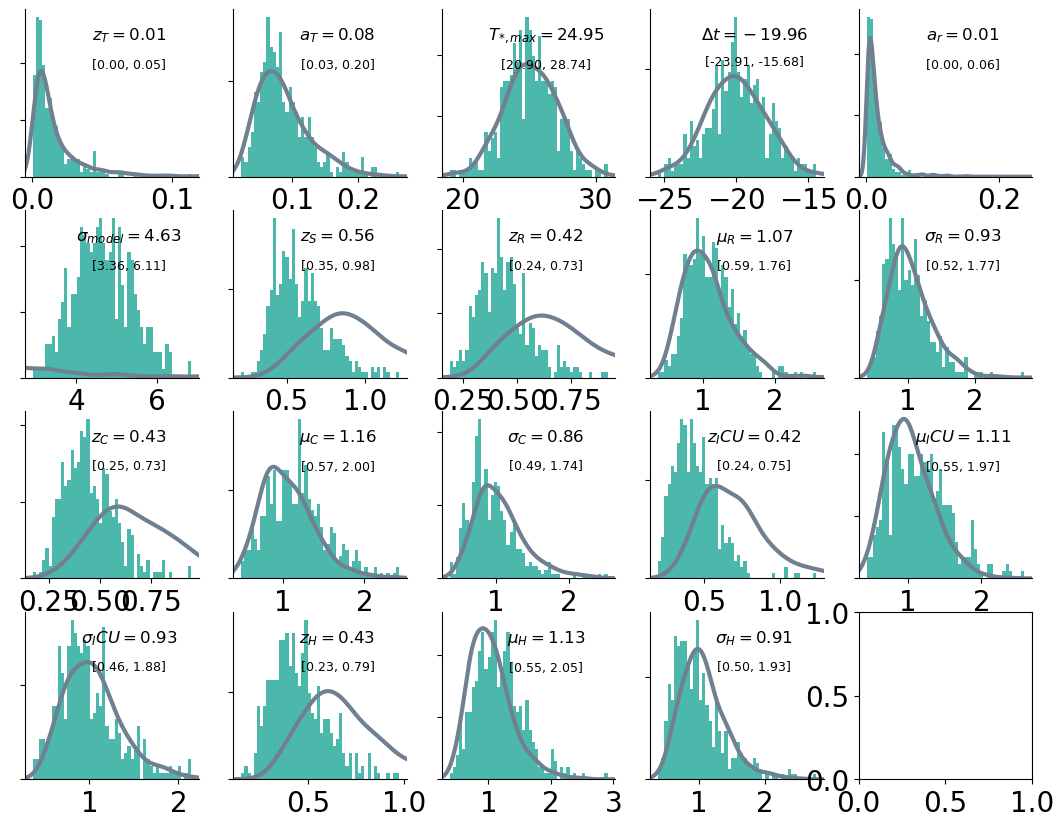

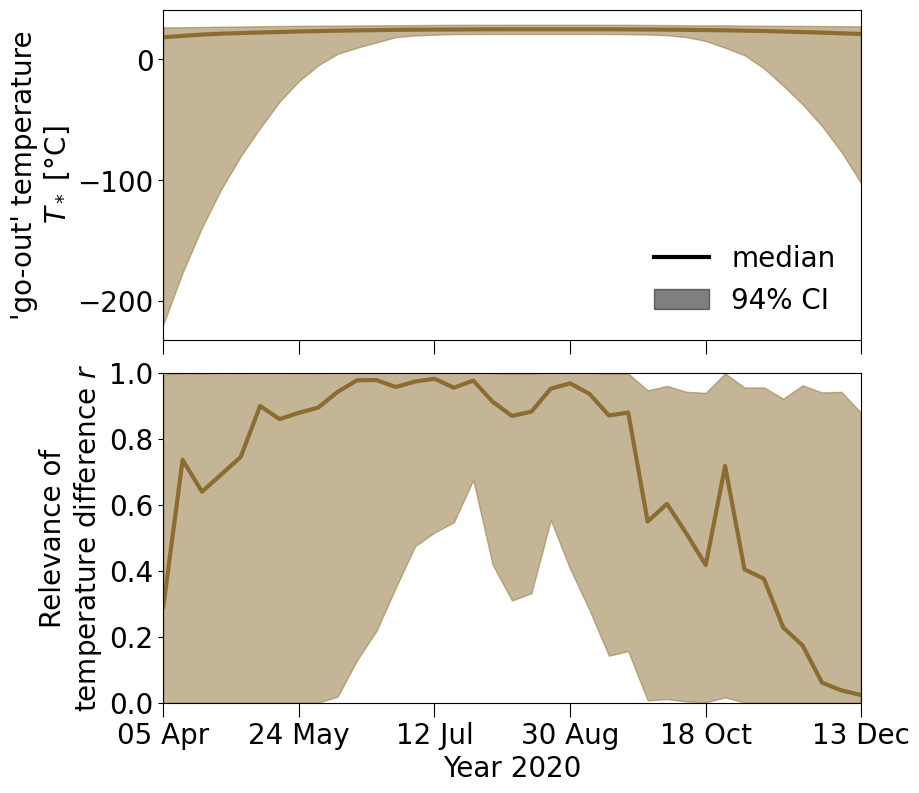

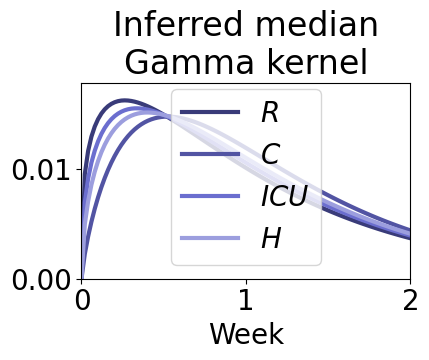

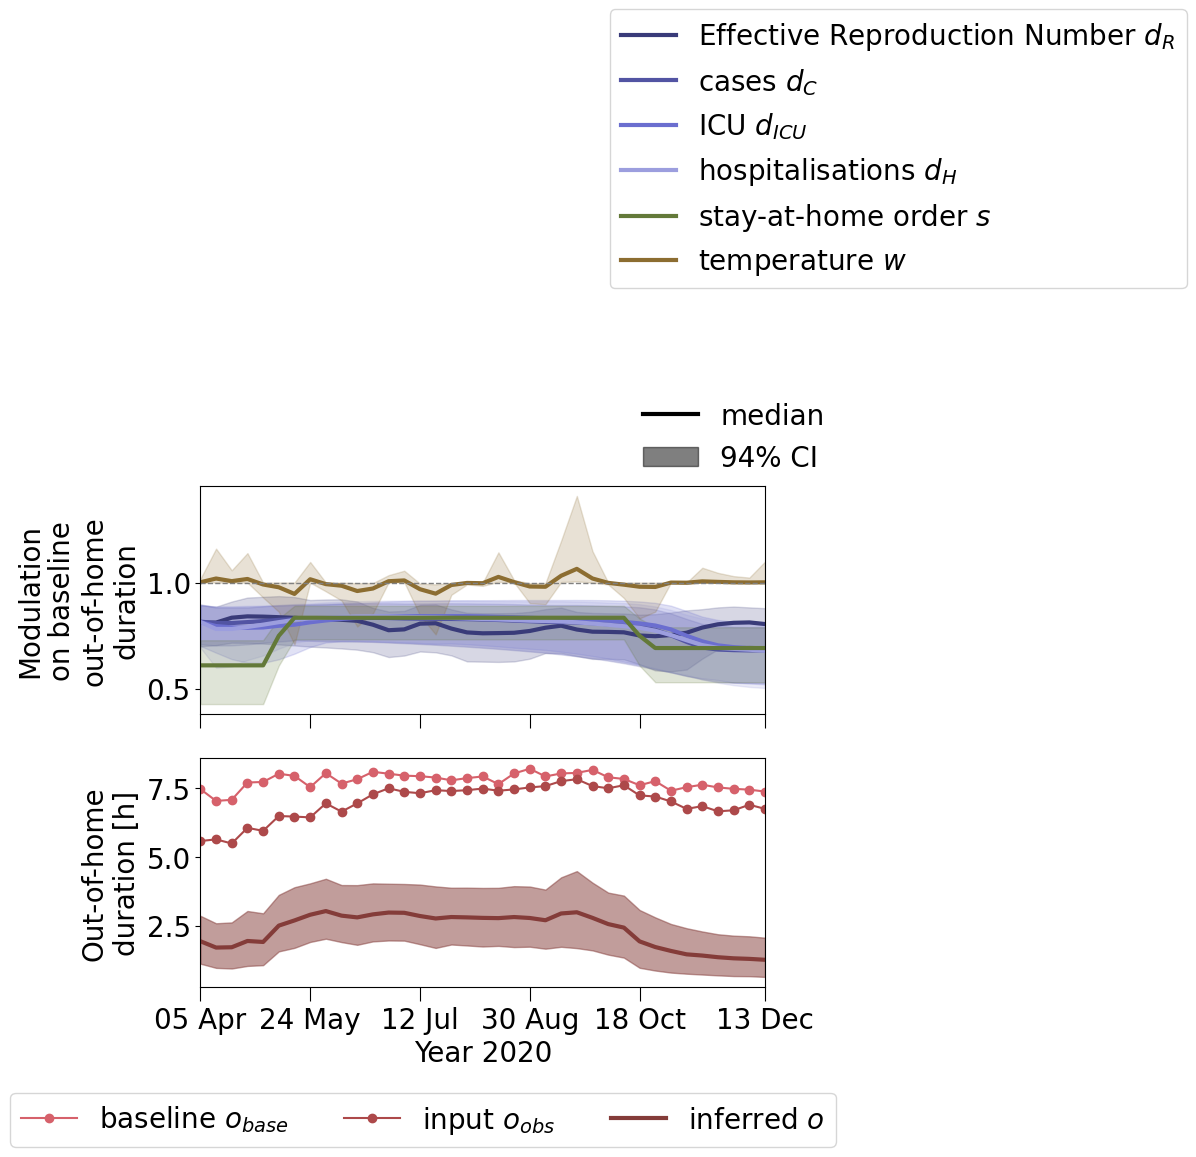

In [28]:
plot.analysis_figures(all_model, all_trace, tag, dates, indicators)

# Comparison

In [29]:
with ICU_model:
    pm.compute_log_likelihood(ICU_trace)

/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

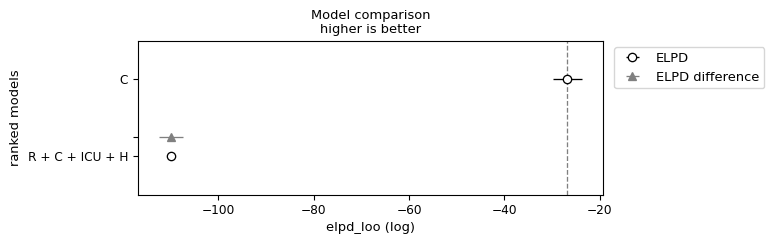

In [31]:
loo = az.compare({
    #"R + ICU": joint_trace, 
    #"R": R_trace, 
    #"ICU": ICU_trace,
    "C": C_trace,
    #"R + C": RC_trace,
    "R + C + ICU + H": all_trace
    }, ic="loo")
az.plot_compare(loo)

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_waic (log)', ylabel='ranked models'>

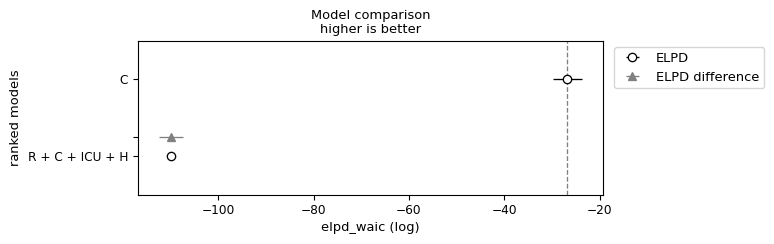

In [32]:
waic = az.compare({
    #"R + ICU": joint_trace, 
    #"R": R_trace, 
    #"ICU": ICU_trace,
    "C": C_trace,
    #"R + C": RC_trace,
    "R + C + ICU + H": all_trace
    }, ic="waic")
az.plot_compare(waic)